## Neural Network to predict 2016 election with 2012 data
Some code is copy pasted from Ex10 
1. import packages
2. read in data
3. train/test split
4. 

In [39]:
#import and install needed packages
import torch
from torchvision import datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader as DataLoader
from torchvision import transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import torchvision
import pandas as pd

In [67]:
#Read in data & remove some rows to avoid Na
df = pd.read_csv("data/df_top25_cramersv_2012.csv") # change 2016 to 2012 for the different years

df.replace('__NA__', np.nan, inplace=True) #correctly read in NA values
print(df.shape)

df = df.dropna()
df = df[df["presvote16post_2016"].isin(["Hillary Clinton", "Donald Trump"])]

df.head()
print(df.shape)


(4585, 26)
(4585, 26)


In [68]:
# defining y and x
y = df["presvote16post_2016"]
y = y.map({
    "Hillary Clinton": 1,
    "Donald Trump": 0
})
X = df.drop(columns=["presvote16post_2016"])
#X = X.drop(columns=["Unnamed: 0"])

# --- one-hot encode ---
X_oh = pd.get_dummies(X, drop_first=False, dtype=int)

#X_oh = X_oh.to_numpy(dtype=np.float32)

# convert to tensor
#X_tensor = torch.tensor(X_oh)

for col in X_oh.columns:
    X_oh[col] = X_oh[col].astype("category").cat.codes
#X_oh = pd.get_dummies(X_oh, dtype=float)
X_tensor = X_oh.apply(pd.to_numeric, errors="raise")
#print(X_oh.dtypes.value_counts())
#print(X_oh.select_dtypes(include=["object"]).columns)


In [69]:
# splitting int o train and test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_oh, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
#creating ML 

#feedforward neural network for tabular data; https://medium.com/@kdk199604/tabnet-a-deep-learning-breakthrough-for-tabular-data-bcd39c47a81c
import torch
import torch.nn as nn

class TabularNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
                    )
        
#criterion = nn.BCEWithLogitsLoss()

    
    def forward(self, x):
        return self.model(x)

In [71]:
#defining train, test, x, y data for model
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [72]:
#train model
model = TabularNN(X_oh.shape[1])

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(20):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

In [73]:
#test model
model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)

    test_probs = torch.sigmoid(test_outputs)
    test_preds = (test_probs > 0.5).float()

    accuracy = (test_preds == y_test_tensor).float().mean()

print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.9465649127960205


In [61]:
with torch.no_grad():
    train_outputs = model(X_train_tensor)
    train_probs = torch.sigmoid(train_outputs)
    train_preds = (train_probs > 0.5).float()

    train_acc = (train_preds == y_train_tensor).float().mean()

print("Train Accuracy:", train_acc.item())

Train Accuracy: 0.949999988079071


In [62]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_probs = torch.sigmoid(test_outputs)
    test_preds = (test_probs > 0.5).int().numpy().flatten()
    y_true = y_test_tensor.int().numpy().flatten()

In [63]:
cm = confusion_matrix(y_true, test_preds)
print(cm)

[[540  42]
 [ 14 559]]


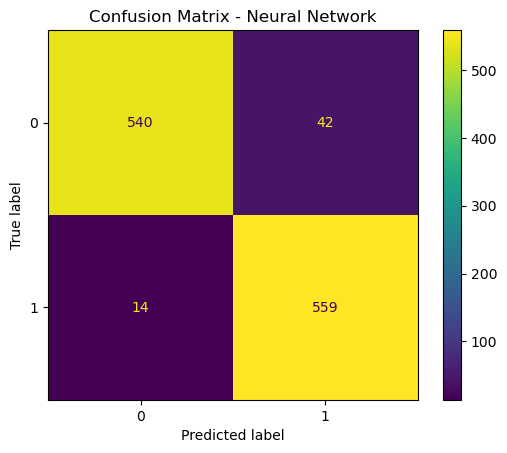

In [64]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Neural Network")
plt.savefig("results/presentation_plots/confusionmatrix_nn_dv.png", dpi = 600)
plt.show()

In [ ]:
"""
Value	Meaning
TN	correctly predicted Trump
TP	correctly predicted Clinton
FP	predicted Clinton but was Trump
FN	predicted Trump but was Clinton

"""

In [ ]:
print(y_train.value_counts(normalize=True))
print("Mean probability:", test_probs.mean())
print("Min:", test_probs.min())
print("Max:", test_probs.max())